Imports

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

Visualizing an image

In [4]:
# load image
image_path = "image.jpg"

img_bgr = cv2.imread(image_path)

if img_bgr is None:
  raise ValueError("Image not found")

# opencv loads as BGR -> convert to RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# normalize to [0, 1]
img_rgb = img_rgb.astype(np.float32) / 255.0

print("Shape: ", img_rgb.shape)

Shape:  (360, 635, 3)


Extraacting the intensity channel

In [5]:
intensity = np.mean(img_rgb, axis=2)
print("Intensity shape:", intensity.shape)

Intensity shape: (360, 635)


Visualization of both RGB and intesity map

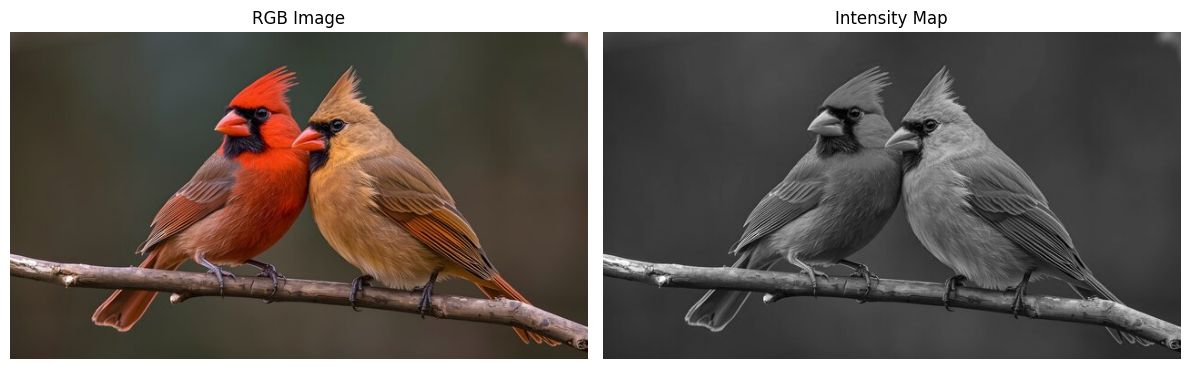

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(img_rgb)
ax[0].set_title("RGB Image")
ax[0].axis("off")

ax[1].imshow(intensity, cmap='gray')
ax[1].set_title("Intensity Map")
ax[1].axis("off")

plt.tight_layout()
plt.show()

Multi-scale Guassian pyramids

In [7]:
def build_gaussian_pyramid(image, levels):
  pyramid = [image]
  current = image.copy()

  for _ in range(levels - 1):
    current = cv2.pyrDown(current)
    pyramid.append(current)

  return pyramid

Intensity pyramid

In [8]:
intensity_pyramid = build_gaussian_pyramid(intensity, levels=9)
print("NUmber of pyramid levels: ", len(intensity_pyramid))

NUmber of pyramid levels:  9


Visualize the pyramid

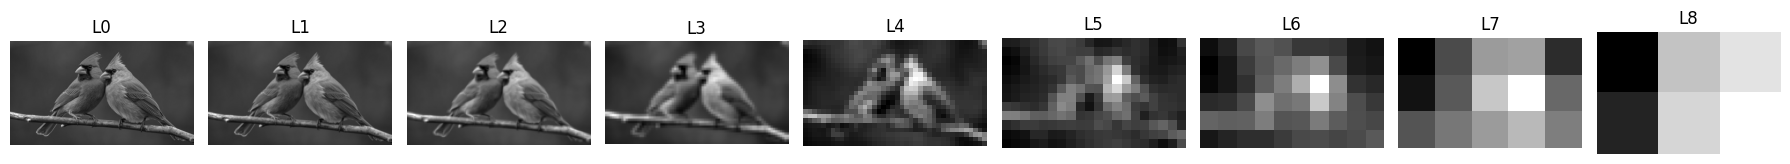

In [10]:
fig, axes = plt.subplots(1, len(intensity_pyramid), figsize=(18, 4))

for i, level in enumerate(intensity_pyramid):
    axes[i].imshow(level, cmap='gray')
    axes[i].set_title(f"L{i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Center surround difference

In [11]:
def center_surround_diff(pyramid, c, s):
  center = pyramid[c]
  surround = pyramid[s]

  # resize surround to center size
  surround_resized = cv2.resize(
      surround,
      (center.shape[1], center.shape[0]),
      interpolation=cv2.INTER_LINEAR
  )

  diff = cv2.absdiff(center, surround_resized)

  return diff

Generating one feature map

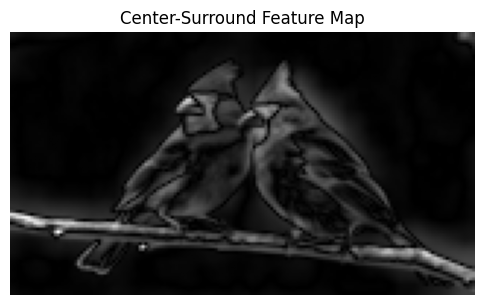

In [12]:
feature_map = center_surround_diff(
    intensity_pyramid,
    c=2,
    s=5
)

plt.figure(figsize=(6,6))
plt.imshow(feature_map, cmap='gray')
plt.title("Center-Surround Feature Map")
plt.axis("off")
plt.show()

Generate all center-surround feature maps

In [13]:
feature_maps = []

center_scales = [2, 3, 4]
delta_scales = [3, 4]

for c in center_scales:
  for delta in delta_scales:
    s = c + delta

    fmap = center_surround_diff(
        intensity_pyramid,
        c = c,
        s = s
    )

    feature_maps.append(fmap)

print("Total feature maps: ", len(feature_maps))

Total feature maps:  6


Visualize them all

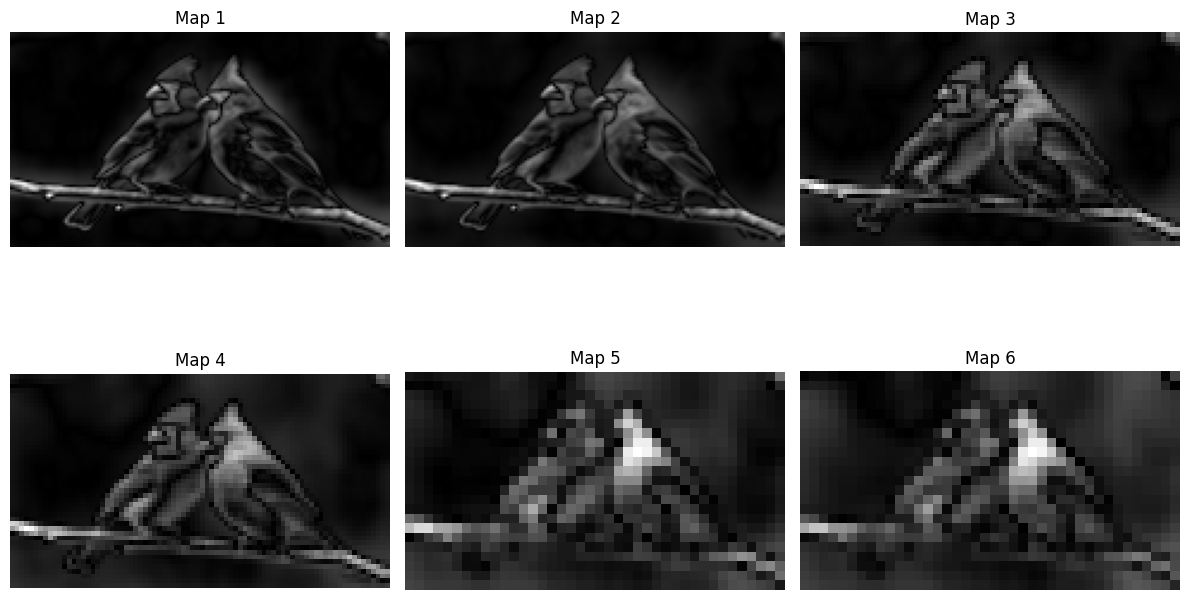

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, fmap, idx in zip(axes.flat, feature_maps, range(len(feature_maps))):
    ax.imshow(fmap, cmap='gray')
    ax.set_title(f"Map {idx+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
def normalize_map(feature_map):
    fmap = feature_map.copy()

    fmap = cv2.normalize(
        fmap,
        None,
        alpha=0,
        beta=1,
        norm_type=cv2.NORM_MINMAX
    )

    mean_val = np.mean(fmap)
    max_val = np.max(fmap)

    fmap = fmap * ((max_val - mean_val) ** 2)

    return fmap

normalize all feature maps

In [16]:
normalized_maps = [
    normalize_map(fmap)
    for fmap in feature_maps
]

Combining them into intensity conspicuity map

In [17]:
base_shape = normalized_maps[0].shape

intensity_conspicuity = np.zeros(base_shape, dtype=np.float32)

for fmap in normalized_maps:
    resized = cv2.resize(
        fmap,
        (base_shape[1], base_shape[0])
    )

    intensity_conspicuity += resized

# Final normalization
intensity_conspicuity = cv2.normalize(
    intensity_conspicuity,
    None,
    0,
    1,
    cv2.NORM_MINMAX
)

Visualize it

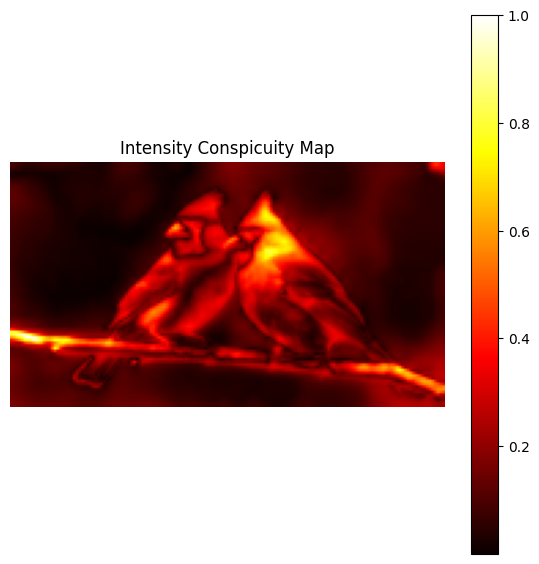

In [18]:
plt.figure(figsize=(7,7))

plt.imshow(intensity_conspicuity, cmap='hot')
plt.title("Intensity Conspicuity Map")
plt.axis("off")

plt.colorbar()
plt.show()